In [1]:
from math import sqrt
from pathlib import Path
from time import time

import pandas as pd
import numpy as np
from numpy.ma.core import inner

import matplotlib.pyplot as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error
import statsmodels.api as sm

from variables import ALLCLINICAL06_VARS



### Store TXT files as CSV

In [2]:
input_path = Path("data/input")
output_path = Path("data/output")

In [3]:
for file_path in input_path.iterdir():
    file = pd.read_csv(file_path, sep="|")
    file.to_csv(file_path.with_suffix(".csv"), sep="|", index=False)

### Explore AllClinical06

In [3]:
# Read file
all_clinical_06 = pd.read_csv(input_path / "AllClinical06.csv", sep="|")

### Exploring missing data

In [4]:
print("Missing columns:")
for col in all_clinical_06:
    missing = all_clinical_06[col].isna().sum()
    print(f"{col}: {missing}/{len(all_clinical_06[col])}")

Missing columns:
ID: 0/4796
VERSION: 0/4796
V06BLDRAW2: 4779/4796
V06ILLPWK2: 4778/4796
V06MULTST2: 4783/4796
V06URINOB1: 978/4796
V06PLAQHR1: 1037/4796
V06BLUPMN2: 4784/4796
V06HOURSP2: 4785/4796
V06VCOLL2: 4783/4796
V06ILLPWK1: 992/4796
V06MULTST1: 1004/4796
V06VEIN2: 4783/4796
V06URUPMN2: 4787/4796
V06VCOLL1: 1005/4796
V06HOURSP1: 1022/4796
V06HRSUC1: 1020/4796
V06URNCOLL: 540/4796
V06EXCESS2: 4783/4796
V06BLDRAW1: 996/4796
V06URINHR1: 1004/4796
V06HRSUC2: 4787/4796
V06QOVP1: 1005/4796
V06EXCESS1: 1005/4796
V06BLDCOLL: 540/4796
V06SEAQHR1: 1023/4796
V06VOID1: 550/4796
V06QOVP2: 4783/4796
V06VEIN1: 1004/4796
V06OTHVP1: 1004/4796
V06SEAQHR2: 4785/4796
V06OTHVP2: 4783/4796
V06URINHR2: 4787/4796
V06HEMAT1: 1005/4796
V06LEAKAG2: 4783/4796
V06BLSURD1: 4003/4796
V06BLDHRS1: 1021/4796
V06URSURD1: 3995/4796
V06URUPMN1: 1012/4796
V06HEMAT2: 4783/4796
V06LEAKAG1: 1005/4796
V06BLSURD2: 4793/4796
V06VOID2: 4659/4796
V06PLAQHR2: 4785/4796
V06URINOB2: 4665/4796
V06BLDHRS2: 4784/4796
V06URSURD2: 47

# Create working dataframes

## Create Subject Summary Metrics dataframe

In [5]:
summary_metrics_06 = pd.DataFrame()

# define columns from all_clinical_06
cols = [
    # basic parameter"ID",
    "ID", "V06AGE", "V06WEIGHT", "V06HEIGHT", "V06BMI",
    # pain parameter
    "V06KOOSKPR", "V06P7RKACV", "V06P7RKRCV", "V06KOOSKPL", "V06P7LKACV", "V06P7LKRCV", "V06KGLRS",
    # sleep parameter
    "V06CESD11", "V06WPLKN3", "V06WPRKN3",
    # accelerometer parameter
    "V06AACNT", # average daily counts
    "V06AALTMNT", # average daily light activity counts Trioano
    "V06AAMDMNT", # average daily moderate activity counts Trioano
    "V06AAMVMNT", # average daily moderate/vigorous activity counts Trioano
    "V06AAVMNT", # average daily vigorous activity counts Trioano
    "V06AAMVBMT", # average daily bout minutes moderate/vigorous Trioano
    "V06AAVBMT", # average daily bout minutes vigorous Trioano
    "V06ANVDAYS", # number of valid days

    "V06AACSM03", # >= 30 minutes of moderate-intensity activity per day 0-1
    "V06ADHHS8", # >= 150 minutes of moderate activity and >=75 minutes of vigorous minutes per week 0 or 1
    "V06ADHHSD8", # >= 150 minutes of moderate-intensity activity per week 0 or 1
]

summary_metrics_06 = all_clinical_06[cols]

### aggregate x-ray dataset for merge

In [6]:
xr_df = pd.read_csv(input_path / "KXR_SQ_BU06.csv", sep="|")

# select Kellgren and Lawrence Score and take max grade per ID and side
xr_df_grade = xr_df[["ID", "SIDE", "V06XRKL"]]
xr_df_grade = xr_df_grade.groupby(["ID", "SIDE"])["V06XRKL"].max().reset_index()

# clean label format from SIDE and V06XRKL (e.g. "1: Right" --> "Right", "2: 2" -> "2")
xr_df_grade["SIDE"] = xr_df_grade["SIDE"].str.extract(r":\s*(\w+)")
xr_df_grade["V06XRKL"] = xr_df_grade["V06XRKL"].str.extract(r":\s*(\d+)").squeeze().astype(float).astype("Int64")

# Pivot from long to wide format -> one row per ID, separate columns for Left and Right
xr_df_wide = xr_df_grade.pivot(index="ID", columns="SIDE", values="V06XRKL")
xr_df_wide.columns = [f"V06XRKL_{col}" for col in xr_df_wide.columns]
xr_df_wide = xr_df_wide.reset_index()

"""
V06XRKL" defines Kellgren and Lawrence grade from 0-4

0 = none (definite absence of x-ray changes of osteoarthritis)
1 = doubtful (doubtful joint space narrowing and possible osteophytic lipping)
2 = minimal (definite osteophytes and possible joint space narrowing)
3 = moderate (moderate multiple osteophytes, definite narrowing of joint space, some sclerosis and possible deformity of bone ends)
4 = severe (large osteophytes, marked narrowing of joint space, severe sclerosis and definite deformity of bone ends)
"""

'\nV06XRKL" defines Kellgren and Lawrence grade from 0-4\n\n0 = none (definite absence of x-ray changes of osteoarthritis)\n1 = doubtful (doubtful joint space narrowing and possible osteophytic lipping)\n2 = minimal (definite osteophytes and possible joint space narrowing)\n3 = moderate (moderate multiple osteophytes, definite narrowing of joint space, some sclerosis and possible deformity of bone ends)\n4 = severe (large osteophytes, marked narrowing of joint space, severe sclerosis and definite deformity of bone ends)\n'

### Aggregate Enrollees for SEX column

In [7]:
enrollees_df = pd.read_csv(input_path / "Enrollees.csv", sep="|")

#clean label format from P02SEX (e.g. "1: Male" --> "Male")
enrollees_df["P02SEX"] = enrollees_df["P02SEX"].str.extract(r":\s*(\w+)")


### merge summary_metrics_06 with x-ray (KL grade) and enrollees (sex)

In [8]:
summary_metrics_06 = (summary_metrics_06
                      .merge(xr_df_wide, on="ID", how="inner")
                      .merge(enrollees_df[["ID", "P02SEX"]], on="ID", how="inner")
                      )


In [9]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)
print(summary_metrics_06.shape)

(3664, 29)


## Create Daily Metrics dataframe

In [10]:
pd.read_csv(input_path / "AccelDataByDay06.csv", sep="|")

daily_metrics_06 = pd.DataFrame()

# define columns from AccelDataByDay06
cols = [
    "ID",
    "V06PAWeekDay",
    "V06PAStudyDay",
    "V06DAYCnt", # total counts per day
    "V06DAYLtMinT", # minutes of light activity (Troiano)
    "V06DAYModMinT", # minutes of moderate activity (Troiano)
    "V06DAYVigMinT", # minutes of vigorous activity (Troiano)
    "V06DAYMVMinT", # minutes of moderate to vigorous activity (Troiano)
    "V06DAYMVBoutMinT", # bout minutes of moderate/vigorous activity (Troiano)
    "V06DAYVBoutMinT", # bout minutes of vigorous activity (Troiano)
    "V06WearHr", # wear time in minutes
    ]

daily_metrics_06 = pd.read_csv(input_path / "AccelDataByDay06.csv", sep="|")[cols]

## Create Minute Metrics dataframe

In [11]:
Acceldatabymin06 = pd.read_csv(input_path / "Acceldatabymin06.csv", sep="|")

# Create minute metrics dataframe
pd.read_csv(input_path / "Acceldatabymin06.csv", sep="|")

minute_metrics_06 = pd.DataFrame()

# define columns from Acceldatabymin06
cols = [
    "ID",
    "V06PAStudyDay",
    "V06PAWeekDay",
    "V06MinSequence",
    "V06MINCnt",
    "V06SuspectMinute"
]

minute_metrics_06 = Acceldatabymin06[cols]

In [12]:
# include KL grade to minute dataframe

kl_grade_per_patient = (
    xr_df_wide[["ID", "V06XRKL_Left", "V06XRKL_Right"]]
    .copy()
)
kl_grade_per_patient["kl_grade"] = kl_grade_per_patient[
    ["V06XRKL_Left", "V06XRKL_Right"]
].max(axis=1)

minute_metrics_06 = minute_metrics_06.merge(
    kl_grade_per_patient[["ID", "kl_grade"]],
    on="ID",
    how="left",
)

In [13]:
minute_metrics_06.to_csv(output_path / "minute_metrics_06.csv", sep="|", index=False)

# Exploring and defining parameters

## Pain

In [14]:
# explore data

pain = all_clinical_06[[
    "ID",
    "V06KOOSKPR",  # Right knee: KOOS Pain Score, 0-100
    # "V06WOMKPR",   # Right knee: WOMAC Pain Score, 0-20
    "V06CPSKR",  # ICOAP Right knee: Constant Pain Score, 0-100
    "V06IPSKR",  # ICOAP Right knee: Intermittent Pain Score, 0-100
    "V06ICPTSKR",  # ICOAP Right knee: Intermittent and Constant Pain Total Score, 0-100
    "V06P7RKFR",  # Right knee pain: how often, 0-4 (never, monthly, weekly, daily, always)
    "V06P7RKACV",  # Right knee pain: on average, past 7 days, rated on scale of 0-10
    "V06P7RKRCV",  # Right knee pain: severity, past 7 days, rated on scale of 0-10

    "V06KOOSKPL",  # Left knee: KOOS Pain Score (calc)
    # "V06WOMKPL",  # Left knee: WOMAC Pain Score (calc)
    "V06CPSKL",  # ICOAP Left knee: Constant Pain Score (calc)
    "V06IPSKL",  # ICOAP Left knee: Intermittent Pain Score (calc)
    "V06ICPTSKL",  # ICOAP Left knee: Intermittent and Constant Pain Total Score (calc)
    "V06P7LKFR",  # Left knee pain: how often
    "V06P7LKACV",  # Left knee pain: on average, past 7 days, rated on scale of 0-10 (calc)
    "V06P7LKRCV",  # Left knee pain: severity, past 7 days, rated on scale of 0-10 (calc)

    "V06KGLRS",  # Considering all ways knee pain and arthritis affect you, how are you doing today? (0–10 scale)
]]

print("Missing columns:")
for col in pain:
    missing = pain[col].isna().sum()
    print(f"{col}: {missing}/{len(pain[col])}")

pain = pain.set_index("ID")
pain = pain.dropna(how="all")

pain.to_csv(output_path / "pain.csv", sep="|", index=False)

print(pain.corr())


Missing columns:
ID: 0/4796
V06KOOSKPR: 562/4796
V06CPSKR: 888/4796
V06IPSKR: 889/4796
V06ICPTSKR: 892/4796
V06P7RKFR: 590/4796
V06P7RKACV: 591/4796
V06P7RKRCV: 590/4796
V06KOOSKPL: 564/4796
V06CPSKL: 888/4796
V06IPSKL: 892/4796
V06ICPTSKL: 893/4796
V06P7LKFR: 589/4796
V06P7LKACV: 589/4796
V06P7LKRCV: 590/4796
V06KGLRS: 558/4796
            V06KOOSKPR  V06CPSKR  V06IPSKR  V06ICPTSKR  V06P7RKFR  V06P7RKACV  \
V06KOOSKPR    1.000000 -0.557875 -0.697575   -0.811913  -0.812341   -0.831895   
V06CPSKR     -0.557875  1.000000  0.216157    0.636900   0.356842    0.470104   
V06IPSKR     -0.697575  0.216157  1.000000    0.890388   0.634891    0.628094   
V06ICPTSKR   -0.811913  0.636900  0.890388    1.000000   0.667960    0.716490   
V06P7RKFR    -0.812341  0.356842  0.634891    0.667960   1.000000    0.705420   
V06P7RKACV   -0.831895  0.470104  0.628094    0.716490   0.705420    1.000000   
V06P7RKRCV   -0.847435  0.435892  0.703792    0.759700   0.771560    0.870655   
V06KOOSKPL    0.56405

In [15]:
# correlations right knee

right_knee_pain = all_clinical_06[["V06KOOSKPR", "V06P7RKFR", "V06P7RKACV", "V06P7RKRCV", "V06KGLRS"]]

print(right_knee_pain.corr())



            V06KOOSKPR  V06P7RKFR  V06P7RKACV  V06P7RKRCV  V06KGLRS
V06KOOSKPR    1.000000  -0.812341   -0.831895   -0.847435 -0.638868
V06P7RKFR    -0.812341   1.000000    0.705420    0.771560  0.489819
V06P7RKACV   -0.831895   0.705420    1.000000    0.870655  0.624710
V06P7RKRCV   -0.847435   0.771560    0.870655    1.000000  0.591812
V06KGLRS     -0.638868   0.489819    0.624710    0.591812  1.000000


## Sleep

In [16]:
# explore sleep parameters, explore missing data, remove columns with > 1000 missing data

sleep = all_clinical_06[["ID", "V06CESD11", "V06WPLKN3", "V06WPRKN3"]]

###
# "V06CESD11",  # FU SAQ:Q31k.CES-D: how often sleep was restless, past week 0-3
# "V06WPLKN3",  # FU INT:*Left knee pain: in bed, last 7 days, 0-4
# "V06WPRKN3",  # FU INT:*Right knee pain: in bed, last 7 days, 0-4
# "V06CPLKN2",  # FU INT:Q53r.ICOAP: Left knee constant pain: how much affected sleep, past 7 days
# "V06CPRKN2",  # FU INT:Q53d.ICOAP: Right knee constant pain: how much affected sleep, past 7 days
# '"V06IPLKN3",  # FU INT:Q53y.ICOAP: Left knee intermittent pain: how much affected sleep, past 7 days
# "V06IPRKN3",  # FU INT:Q53k.ICOAP: Right knee intermittent pain: how much affected sleep, past 7 days

print("Missing columns:")
for col in sleep:
    missing = sleep[col].isna().sum()
    print(f"{col}: {missing}/{len(sleep[col])}")

sleep = sleep.set_index('ID')
sleep = sleep.dropna(how="all")

Missing columns:
ID: 0/4796
V06CESD11: 768/4796
V06WPLKN3: 563/4796
V06WPRKN3: 564/4796


In [17]:
# define sleep score scale 0-10
sleep["max_pain_bed"] = sleep[["V06WPLKN3", "V06WPRKN3"]].max(axis=1)
sleep["sleep_score"] = ((sleep["max_pain_bed"] + sleep["V06CESD11"]) / 7 * 10).round(1)

In [18]:
# merge sleep_score to summary_metrics_06 and save as .csv
summary_metrics_06 = summary_metrics_06.merge(sleep['sleep_score'], on="ID", how="inner")


In [19]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)

In [20]:
print(summary_metrics_06.head())
print(summary_metrics_06.shape)

        ID  V06AGE  V06WEIGHT  V06HEIGHT  V06BMI  V06KOOSKPR  V06P7RKACV  \
0  9000099    63.0       81.0     1810.0    24.7        97.2         0.0   
1  9000296    73.0       80.1     1680.0    28.4        91.7         0.0   
2  9000798    60.0      109.7     1790.0    34.2       100.0         0.0   
3  9001695    56.0       80.5     1650.0    29.6        75.0         2.0   
4  9001897    76.0       79.5     1775.5    25.2       100.0         0.0   

   V06P7RKRCV  V06KOOSKPL  V06P7LKACV  ...  V06AAMVBMT  V06AAVBMT  V06ANVDAYS  \
0         0.0        97.2         0.0  ...   64.400000        0.0         5.0   
1         4.0       100.0         0.0  ...         NaN        NaN         NaN   
2         0.0        78.1         3.0  ...         NaN        NaN         NaN   
3         2.0       100.0         0.0  ...    3.000000        0.0         7.0   
4         0.0       100.0         0.0  ...    5.142857        0.0         7.0   

   V06AACSM03  V06ADHHS8  V06ADHHSD8  V06XRKL_Left  V06X

## Activity

### Aggregate wake and sleep time

In [21]:
def compute_wake_sleep_time(df: pd.DataFrame, id_col: str = "ID", day_col: str = "V06PAStudyDay",
                            min_col: str = "V06MinSequence", activity_count_col: str = "V06MINCnt",
                            suspect_col: str = "V06SuspectMinute") -> tuple[pd.DataFrame, pd.DataFrame]:
    """
    computes Wake Time (first active minute) and Sleep Time (last active minute) per ID and day
    Returns:
        daily_wake_sleep_metrics: ID, Day, wake_minute, sleep_minute, wake_time_hhmm, sleep_time_hhmm
        id_agg_wake_sleep_metrics: ID, aggregated Wake/Sleep mean and sds
    """

# function to convert minute of day to HH:MM format, minute 1 = 00:01, minute 1440 = 24:00

    def minute_to_hhmm(m):
        if pd.isna(m):
            return np.nan
        h = int((m - 1) // 60)
        mins = int((m - 1) % 60)
        return f"{h:02d}:{mins:02d}"

    results = []

# filter per ID and day, only non-suspect minutes, sort by minute sequence, find first and last active minute (activity count > 0)

    for (id, day), grp in df.groupby([id_col, day_col]):

        grp_filtered = grp[grp[suspect_col] == 0].sort_values(min_col)
        active = grp_filtered[grp_filtered[activity_count_col] > 0][min_col].values

        if len(active) == 0:
            results.append({
                id_col: id,
                day_col: day,
                "weekday": grp["V06PAWeekDay"].iloc[0],
                "wake_minute": np.nan,
                "sleep_minute": np.nan,
            })
            continue

        results.append({
            id_col: id,
            day_col: day,
            "weekday": grp["V06PAWeekDay"].iloc[0],
            "wake_minute": active[0],  # first active minute
            "sleep_minute": active[-1],  # last active minute
        })

    daily_wake_sleep_metrics = pd.DataFrame(results)

    daily_wake_sleep_metrics["wake_time_hhmm"] = daily_wake_sleep_metrics["wake_minute"].apply(minute_to_hhmm)
    daily_wake_sleep_metrics["sleep_time_hhmm"] = daily_wake_sleep_metrics["sleep_minute"].apply(minute_to_hhmm)
    daily_wake_sleep_metrics["wear_duration_min"] = daily_wake_sleep_metrics["sleep_minute"] - daily_wake_sleep_metrics["wake_minute"]

    # aggregate per ID across days

    id_agg_wake_sleep_metrics = (
        daily_wake_sleep_metrics.groupby(id_col).agg(
            wake_minute_mean=("wake_minute", np.mean),
            wake_minute_sd=("wake_minute", np.std),
            sleep_minute_mean=("sleep_minute", np.mean),
            sleep_minute_sd=("sleep_minute", np.std),
            wear_duration_mean=("wear_duration_min", np.mean),
            n_valid_days=("wake_minute", "count"),
        )
        .reset_index()
    )

    id_agg_wake_sleep_metrics["wake_mean_hhmm"] = id_agg_wake_sleep_metrics["wake_minute_mean"].apply(minute_to_hhmm)
    id_agg_wake_sleep_metrics["sleep_mean_hhmm"] = id_agg_wake_sleep_metrics["sleep_minute_mean"].apply(minute_to_hhmm)

    return daily_wake_sleep_metrics, id_agg_wake_sleep_metrics

In [22]:
daily_wake_sleep_metrics_06, id_agg_wake_sleep_metrics_06 = compute_wake_sleep_time(minute_metrics_06)
summary_metrics_06 = summary_metrics_06.merge(id_agg_wake_sleep_metrics_06, on="ID", how="left")
daily_metrics_06 = daily_metrics_06.merge(daily_wake_sleep_metrics_06, on=["ID", "V06PAStudyDay"], how="left")

In [23]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)
daily_metrics_06.to_csv(output_path / "daily_metrics_06.csv", sep="|", index=False)

### Define sedentary counts to daily_metrics

In [24]:
daily_metrics_06["sedentary"] = daily_metrics_06["wear_duration_min"] - daily_metrics_06["V06DAYLtMinT"] - daily_metrics_06["V06DAYModMinT"] - daily_metrics_06["V06DAYVigMinT"]


In [25]:
daily_metrics_06.to_csv(output_path / "daily_metrics_06.csv", sep="|", index=False)

### Build bout structure for activity patterns

In [26]:
def identify_non_wear_minutes(
        dataframe: pd.DataFrame,
        non_wear_threshold_minutes: int = 90,
) -> pd.Series:

    """
    Identify non-wear minutes using a rolling window of consecutive zero
    activity counts per participant and study day.
    Non-wear periods are identified using the OAI-specific threshold of 90
    consecutive minutes of zero activity counts, which was validated for
    rheumatic disease populations.
    """

    is_non_wear = pd.Series(False, index=dataframe.index)

    for(id, study_day), group in dataframe.groupby(["ID", "study_day"]):

        zero_counts = group["counts"] == 0
        consecutive_zero_count = 0
        group_non_wear = pd.Series(False, index=group.index)
        bout_start_index = None

        for index, is_zero in zero_counts.items():
            if is_zero:
                if consecutive_zero_count == 0:
                    bout_start_index = index
                consecutive_zero_count += 1
            else:
                if consecutive_zero_count >= non_wear_threshold_minutes:
                    group_non_wear.loc[bout_start_index:index - 1] = True
                consecutive_zero_count = 0
                bout_start_index = None

        if consecutive_zero_count >= non_wear_threshold_minutes:
            group_non_wear.loc[bout_start_index:] = True


        is_non_wear.loc[group.index] = group_non_wear

    return is_non_wear

def assign_intensity_labels(dataframe: pd.DataFrame) -> pd.Series:

    """
    Assign an intensity label to each minute based on activity counts,
    non-wear status, and suspicious minute flag.

    Labels are assigned in the following priority order (Troiano):
        1. suspicious  — is_suspicious == True
        2. non_wear    — within a 90-minute consecutive zero-count period
        3. sedentary   — 0–99 counts/min (valid wear time)
        4. light       — 100–2019 counts/min
        5. moderate    — 2020–5998 counts/min
        6. vigorous    — >= 5999 counts/min
    """

    conditions = [
        dataframe["is_suspicious"],
        dataframe["is_non_wear"],
        dataframe["counts"] < 100,
        dataframe["counts"] < 2020,
        dataframe["counts"] < 5999,
        ]

    intensity_labels = [
        "suspicious",
        "non_wear",
        "sedentary",
        "light",
        "moderate",
    ]

    return pd.Series(
        np.select(
            condlist=conditions,
            choicelist=intensity_labels,
            default="vigorus",
        ),
        index=dataframe.index,
    )

def classify_activity_level(
        minute_dataframe: pd.DataFrame,
        non_wear_threshold_minutes: int = 90,
) -> pd.DataFrame:

    """
    Classify each minute of accelerometer data into an intensity label and
    add non-wear and suspicious minute flags to the dataframe.
    """

    required_columns = [
        "ID",
        "V06PAStudyDay",
        "V06PAWeekDay",
        "V06MinSequence",
        "V06MINCnt",
        "V06SuspectMinute",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in minute_dataframe.columns
    ]

    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    result_dataframe = minute_dataframe.copy()

    result_dataframe = result_dataframe.rename(
        columns={
            "V06PAStudyDay": "study_day",
            "V06PAWeekDay": "week_day",
            "V06MinSequence": "minute_sequence",
            "V06MINCnt": "counts",
            "V06SuspectMinute": "is_suspicious",
        }
    )

    result_dataframe["is_suspicious"] = (result_dataframe["is_suspicious"] == 1)

    result_dataframe["is_non_wear"] = identify_non_wear_minutes(
        dataframe=result_dataframe,
        non_wear_threshold_minutes=non_wear_threshold_minutes,
    )

    result_dataframe["intensity_label"] = assign_intensity_labels(
        dataframe=result_dataframe,
    )

    return result_dataframe


In [27]:
minute_metrics_06 = classify_activity_level(minute_dataframe=minute_metrics_06,)

In [28]:
minute_metrics_06.to_csv(output_path / "minute_metrics_06.csv", sep="|", index=False)

### Calculate who guidline compliance per day and per week

In [29]:
def calculate_who_guideline_compliance(daily_dataframe: pd.DataFrame) -> pd.DataFrame:
    """
    Calculate WHO guideline compliance for each day based on daily activity metrics.
    WHO guidelines for adults aged 18-64 recommend:
        - At least 150 minutes of moderate-intensity aerobic physical activity per week, or
        - At least 75 minutes of vigorous-intensity aerobic physical activity per week, or
        - An equivalent combination of moderate- and vigorous-intensity activity.

    This function adds a column to the daily_metrics_df indicating whether the
    participant met the WHO guidelines on that day.
    """

    required_columns = [
        "ID",
        "V06PAStudyDay",
        "V06DAYModMinT",
        "V06DAYVigMinT",
    ]

    missing_columns = [
        column for column in required_columns
        if column not in daily_dataframe.columns
    ]
    if missing_columns:
        raise KeyError(
            f"The following required columns are missing: {missing_columns}"
        )

    daily_moderate_guideline_threshold = 150/7
    daily_vigorous_guideline_threshold = 75/7
    weekly_moderate_guideline_threshold = 150
    weekly_vigorous_guideline_threshold = 75
    vigorous_to_moderate_multiplier = 2

    result_dataframe = daily_dataframe.copy()

    result_dataframe["combined_equivalent_minutes"] = (result_dataframe["V06DAYModMinT"] + result_dataframe["V06DAYVigMinT"] * vigorous_to_moderate_multiplier)

    result_dataframe["meets_daily_WHO_guideline"] = (
    (result_dataframe["V06DAYModMinT"] >= daily_moderate_guideline_threshold)
    | (result_dataframe["V06DAYVigMinT"] >= daily_vigorous_guideline_threshold)
    | (result_dataframe["combined_equivalent_minutes"] >= daily_moderate_guideline_threshold)
    )

    weekly_compliance = result_dataframe.groupby("ID").agg(
        total_moderate_minutes=("V06DAYModMinT", "sum"),
        total_vigorous_minutes=("V06DAYVigMinT", "sum"),
        total_combined_equivalent_minutes=("combined_equivalent_minutes", "sum"),
        day_count=("combined_equivalent_minutes", "count"),
    ).reset_index()

    weekly_compliance["meets_weekly_who_guideline"] = (
    (weekly_compliance["total_moderate_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_moderate_guideline_threshold)
    | (weekly_compliance["total_vigorous_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_vigorous_guideline_threshold)
    | (weekly_compliance["total_combined_equivalent_minutes"] / weekly_compliance["day_count"] * 7 >= weekly_moderate_guideline_threshold)
)

    weekly_compliance["weekly_guideline_gap_minutes"] = (
    weekly_compliance["total_combined_equivalent_minutes"] / weekly_compliance["day_count"] * 7
    - weekly_moderate_guideline_threshold
)
    result_dataframe = result_dataframe.merge(
        weekly_compliance[[
            "ID",
            "meets_weekly_who_guideline",
            "weekly_guideline_gap_minutes",
        ]],
        on="ID",
        how="left",
    )

    return result_dataframe

In [30]:
daily_metrics_06 = calculate_who_guideline_compliance(
    daily_dataframe=daily_metrics_06,
)

In [31]:
summary_metrics_06 = summary_metrics_06.merge(
    daily_metrics_06[["ID", "meets_weekly_who_guideline", "weekly_guideline_gap_minutes"]]
    .drop_duplicates(subset="ID"),
    on="ID",
    how="left",
)

In [32]:
summary_metrics_06["comparison"] = np.where(
    summary_metrics_06["V06ADHHS8"].isna()
    | summary_metrics_06["meets_weekly_who_guideline"].isna(),
    np.nan,
    (
        ((summary_metrics_06["V06ADHHS8"] == 1) & (summary_metrics_06["meets_weekly_who_guideline"] == True))
        | ((summary_metrics_06["V06ADHHS8"] == 0) & (summary_metrics_06["meets_weekly_who_guideline"] == False))

    ).map({True: "consistent", False: "inconsistent"}))

In [33]:
summary_metrics_06.to_csv(output_path / "summary_metrics_06.csv", sep="|", index=False)

In [34]:
participant_compliance = daily_metrics_06.groupby("ID")["meets_weekly_who_guideline"].first()

total = len(participant_compliance)
meets_true = participant_compliance.sum()
meets_false = total - meets_true

print(f"Total participants: {total}")
print(f"Meets WHO guideline: {meets_true} ({meets_true/total:.1%})")
print(f"Does not meet WHO guideline: {meets_false} ({meets_false/total:.1%})")

Total participants: 2001
Meets WHO guideline: 647 (32.3%)
Does not meet WHO guideline: 1354 (67.7%)


## aggregate activity bouts

In [21]:
# constants

gap_fill_minutes = 2

time_of_day_bins = {
    "morning": (360, 720),  # 6:00-12:00
    "afternoon": (720, 1080),  # 12:00-18:00
    "evening": (1080, 1440),  # 18:00-24
}

bout_types = ["non active", "light", "moderate", "vigorous"]

# Activity Count/Minute Swartz rounded
activity_threshold_light = 100
activity_threshold_moderate = 600
activity_threshold_vigorous = 5000


# classify activity level per minute

def classify_activity_level(count: int) -> str:
    if count == 0:
        return "non active"
    elif count < activity_threshold_light:
        return "light"
    elif count < activity_threshold_moderate:
        return "moderate"
    else:
        return "vigorous"

In [22]:
from itertools import groupby


# extract bouts of activity per ID and activity level

def extract_bouts(
        activity_level_series: pd.Series,
        minute_sequence: pd.Series,
) -> pd.DataFrame:
    bouts = []
    for activity_level, group in groupby(
            zip(minute_sequence, activity_level_series), key=lambda pair: pair[1]
    ):
        group_list = list(group)
        bouts.append({
            "bout_type": activity_level,
            "start_minute": group_list[0][0],
            "end_minute": group_list[-1][0],
            "duration": len(group_list),
        })
    return pd.DataFrame(bouts)

In [23]:
# merge activity data frames

def activity_df_big(
        Acceldatabymin06: pd.DataFrame,
        daily_df_06: pd.DataFrame,
) -> pd.DataFrame:
    merged = Acceldatabymin06.merge(
        daily_df_06,
        on=["ID", "V06PAStudyDay"],
        how="inner",
    )

    worn = merged[
        (merged["V06SuspectMinute"] == 0) &
        (merged["V06MinSequence"] >= merged["wake_minute"]) &
        (merged["V06MinSequence"] <= merged["sleep_minute"])
        ].copy()

    worn["activity_level"] = worn["V06MINCnt"].apply(classify_activity_level)
    return worn


In [24]:
# bout segmentation

def apply_gap_fill(
        is_active_series: pd.Series,
        maximum_gap_minutes: int = gap_fill_minutes,
) -> pd.Series:
    result = is_active_series.copy()
    values = result.to_numpy(copy=True)  # ensures a writable array
    in_gap = False
    gap_start = None

    for index in range(1, len(values) - 1):
        if values[index - 1] == 1 and values[index] == 0:
            in_gap = True
            gap_start = index
        if in_gap and values[index] == 1:
            gap_length = index - gap_start
            if gap_length <= maximum_gap_minutes:
                values[gap_start:index] = 1
            in_gap = False

    result.iloc[:] = values
    return result


def segment_bouts_for_group(group_df: pd.DataFrame) -> pd.DataFrame:
    group_df = group_df.sort_values("V06MinSequence")

    is_any_active_binary = (group_df["activity_level"] != "non active").astype(int)
    filled_active = apply_gap_fill(is_any_active_binary)

    activity_level_corrected = group_df["activity_level"].copy()
    gap_filled_mask = (
            (filled_active == 1) &
            (group_df["activity_level"] == "non active") &
            (group_df["V06MINCnt"] > 0)
    )
    activity_level_corrected[gap_filled_mask] = "light"

    bouts = extract_bouts(activity_level_corrected, group_df["V06MinSequence"])
    bouts["ID"] = group_df["ID"].iloc[0]
    bouts["V06PAStudyDay"] = group_df["V06PAStudyDay"].iloc[0]
    bouts["V06PAWeekDay"] = group_df["V06PAWeekDay"].iloc[0]
    bouts["kl_grade"] = group_df["kl_grade"].iloc[0]
    return bouts


In [25]:
def compute_daily_metrics(bouts_df: pd.DataFrame) -> pd.DataFrame:
    records = []

    for (patient_id, study_day, kl_grade, weekday), group in bouts_df.groupby(
            ["ID", "V06PAStudyDay", "kl_grade", "V06PAWeekDay"]
    ):
        record = {
            "ID": patient_id,
            "V06PAStudyDay": study_day,
            "kl_grade": kl_grade,
            "V06PAWeekDay": weekday,
        }

        for bout_type in bout_types:
            subset = group[group["bout_type"] == bout_type]
            bout_count = len(subset)

            record[f"{bout_type}_total_minutes"] = subset["duration"].sum()
            record[f"{bout_type}_bout_count"] = bout_count
            record[f"{bout_type}_bout_mean_duration"] = (
                subset["duration"].mean() if bout_count > 0 else np.nan
            )
            record[f"{bout_type}_bout_p90_duration"] = (
                subset["duration"].quantile(0.9) if bout_count > 0 else np.nan
            )
            record[f"{bout_type}_longest_bout"] = (
                subset["duration"].max() if bout_count > 0 else np.nan
            )

        any_active_subset = group[group["bout_type"] != "non active"]
        total_active_minutes = any_active_subset["duration"].sum()
        total_active_bouts = len(any_active_subset)
        record["fragmentation_index"] = (
            total_active_bouts / total_active_minutes
            if total_active_minutes > 0 else np.nan
        )

        moderate_vigorous_subset = group[
            group["bout_type"].isin(["moderate", "vigorous"])
        ]
        for period_name, (start, end) in time_of_day_bins.items():
            record[f"mvpa_minutes_{period_name}"] = moderate_vigorous_subset[
                (moderate_vigorous_subset["start_minute"] >= start) &
                (moderate_vigorous_subset["end_minute"] <= end)
                ]["duration"].sum()

        records.append(record)

    return pd.DataFrame(records)

In [26]:
def run_activity_profile_analysis(
        acceldatabymin06: pd.DataFrame,
        daily_df_06: pd.DataFrame,
) -> tuple[pd.DataFrame, pd.DataFrame]:
    worn_df = activity_df_big(
        Acceldatabymin06=acceldatabymin06,
        daily_df_06=daily_df_06,
    )

    all_bouts = pd.concat([
        segment_bouts_for_group(group)
        for _, group in worn_df.groupby(["ID", "V06PAStudyDay"])
    ], ignore_index=True)

    daily_metrics = compute_daily_metrics(all_bouts)

    return daily_metrics, all_bouts

In [27]:
daily_06_df, aggregated_df = compute_wake_sleep_time(Acceldatabymin06)
daily_metrics, bouts = run_activity_profile_analysis(Acceldatabymin06, daily_06_df)

In [28]:
daily_metrics.to_csv(output_path / "daily_metrics.csv", sep="|", index=False)


In [29]:
print(bouts)

          bout_type  start_minute  end_minute  duration       ID  \
0          vigorous           389         389         1  9000099   
1        non active           390         390         1  9000099   
2          vigorous           391         391         1  9000099   
3          moderate           392         392         1  9000099   
4          vigorous           393         393         1  9000099   
...             ...           ...         ...       ...      ...   
4853868  non active          1294        1296         3  9999878   
4853869       light          1297        1298         2  9999878   
4853870    vigorous          1299        1302         4  9999878   
4853871  non active          1303        1307         5  9999878   
4853872       light          1308        1308         1  9999878   

         V06PAStudyDay V06PAWeekDay kl_grade  
0                  414       Friday        4  
1                  414       Friday        4  
2                  414       Friday       

### merge dataframes with summary_metrics_06

In [30]:
summary_metrics_06 = summary_metrics_06.merge(aggregated_df, on="ID", how="inner")
working_and_daily_minute = summary_metrics_06.merge(daily_06_df, on="ID", how="inner")


In [31]:
print(summary_metrics_06.shape)
print(summary_metrics_06.isnull().sum())

(1951, 51)
ID                     0
V06AGE                 0
V06WEIGHT              6
V06HEIGHT             40
V06BMI                 6
V06KOOSKPR             0
V06P7RKACV            17
V06P7RKRCV            17
V06KOOSKPL             1
V06P7LKACV            17
V06P7LKRCV            17
V06KGLRS               1
V06CESD11             19
V06WPLKN3              1
V06WPRKN3              1
V06AACNT              82
V06AALTMNT            82
V06AALTMNF            82
V06AALTMNS            82
V06AAMDMNT            82
V06AAMDMNF            82
V06AAMDMNS            82
V06AAMVMNT            82
V06AAMVMNF            82
V06AAMVMNS            82
V06AAMVBMT            82
V06AAMVBMF            82
V06AAMVBMS            82
V06AAVMNT             82
V06AAVMNF             82
V06AAVMNS             82
V06AAVBMT             82
V06AAVBMF             82
V06AAVBMS             82
V06AACSM03            82
V06ADHHS8             82
V06ADHHSD8            82
V06AMPA1              82
V06ANVDAYS             0
V06XRKL_Left  

In [32]:

both_null_mask = (summary_metrics_06["V06XRKL_Left"].isnull() & summary_metrics_06["V06XRKL_Right"].isnull()).sum()
print(summary_metrics_06['ID'][both_null_mask])

9001695


## masks for activity parameter

In [21]:
# masks KL grade 0-4 summary_metricx

mask_grade_4 = summary_metrics_06['V06XRKL_Left'].eq(4) | summary_metrics_06['V06XRKL_Right'].eq(4)
mask_grade_3 = summary_metrics_06['V06XRKL_Left'].eq(3) | summary_metrics_06['V06XRKL_Right'].eq(3)
mask_grade_2 = summary_metrics_06['V06XRKL_Left'].eq(2) | summary_metrics_06['V06XRKL_Right'].eq(2)
mask_grade_1 = summary_metrics_06['V06XRKL_Left'].eq(1) | summary_metrics_06['V06XRKL_Right'].eq(1)
mask_grade_0 = summary_metrics_06['V06XRKL_Left'].eq(0) | summary_metrics_06['V06XRKL_Right'].eq(0)

In [23]:
# masks weekday vs. weekend
mask_weekday = working_and_daily_minute['weekday'].isin(["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"])
mask_weekend = working_and_daily_minute['weekday'].isin(["Saturday", "Sunday"])

NameError: name 'working_and_daily_minute' is not defined

In [35]:
print(working_and_daily_minute[mask_weekend].head())

         ID  V06AGE  V06WEIGHT  V06HEIGHT  V06BMI  V06KOOSKPR  V06P7RKACV  \
1   9000099    63.0       81.0     1810.0    24.7        97.2         0.0   
2   9000099    63.0       81.0     1810.0    24.7        97.2         0.0   
6   9001695    56.0       80.5     1650.0    29.6        75.0         2.0   
7   9001695    56.0       80.5     1650.0    29.6        75.0         2.0   
15  9001897    76.0       79.5     1775.5    25.2       100.0         0.0   

    V06P7RKRCV  V06KOOSKPL  V06P7LKACV  ...  n_valid_days  wake_mean_hhmm  \
1          0.0        97.2         0.0  ...             5           07:02   
2          0.0        97.2         0.0  ...             5           07:02   
6          2.0       100.0         0.0  ...             8           05:46   
7          2.0       100.0         0.0  ...             8           05:46   
15         0.0       100.0         0.0  ...            10           07:53   

    sleep_mean_hhmm  V06PAStudyDay   weekday  wake_minute  sleep_minute  \

### correlations

In [36]:
subset = summary_metrics_06[[
    "sleep_score", "V06KOOSKPR",  # 5.1 FU INT: Right knee: KOOS Pain Score (calc)
    "V06P7RKACV",  # Right knee pain: on average, past 7 days, rated on scale of 0-10 (calc)
    "V06P7RKRCV",  # Right knee pain: severity, past 7 days, rated on scale of 0-10 (calc)
    "V06KGLRS",  # Considering all ways knee pain and arthritis affect you, how are you doing today? (0–10 scale),
]]

corr = subset.corr()
corr_pairs = (
    corr.abs()
    .unstack()
    .sort_values(ascending=False)
)

print(corr_pairs[corr_pairs < 1].head(20))


V06P7RKRCV   V06P7RKACV     0.855220
V06P7RKACV   V06P7RKRCV     0.855220
V06P7RKRCV   V06KOOSKPR     0.842779
V06KOOSKPR   V06P7RKRCV     0.842779
             V06P7RKACV     0.826364
V06P7RKACV   V06KOOSKPR     0.826364
V06KOOSKPR   V06KGLRS       0.647151
V06KGLRS     V06KOOSKPR     0.647151
             V06P7RKACV     0.613660
V06P7RKACV   V06KGLRS       0.613660
V06P7RKRCV   V06KGLRS       0.578823
V06KGLRS     V06P7RKRCV     0.578823
V06KOOSKPR   sleep_score    0.530469
sleep_score  V06KOOSKPR     0.530469
V06KGLRS     sleep_score    0.466520
sleep_score  V06KGLRS       0.466520
             V06P7RKACV     0.415733
V06P7RKACV   sleep_score    0.415733
V06P7RKRCV   sleep_score    0.408679
sleep_score  V06P7RKRCV     0.408679
dtype: float64


# Linear regression

In [37]:
def linear_regression_analysis(df: pd.DataFrame, predictor_columns: list[str], target_column: str) -> None:
    """
    Fits a linear regression and provides some analysis on it.
    :param df: The dataframe, containing both the predictor columns and target column.
    :param predictor_columns: List of column names used to predict the target column.
    :param target_column: Single column name of the target column.
    :return: None
    """
    # Drop rows with missing values
    df = df[predictor_columns + [target_column]].dropna()

    X = df[predictor_columns]
    y = df[target_column]

    # Split in train and test set
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

    # Initialize model
    model = LinearRegression()

    # Fit model to training data
    model.fit(X_train, y_train)
    print("--- Fit ---")
    print(f"Coefficients: {model.coef_}")
    print(f"Intercept: {model.intercept_}\n")

    # Predict on test set and compare to actual y_test
    y_pred = model.predict(X_test)
    print("--- Prediction ---")
    print("R²:", r2_score(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", sqrt(mean_squared_error(y_test, y_pred)))

In [38]:
predictor_cols = [
    "V06AAMVMNT", "V06AAMVBMT", "V06AACNT"
]

target_col = "V06P7RKRCV"

linear_regression_analysis(all_clinical_06, predictor_cols, target_col)


# Fehlende Werte entfernen
# data = all_clinical_06[predictor_cols + [target_col]].dropna()


--- Fit ---
Coefficients: [-2.83448029e-02  7.70290671e-03  2.27318383e-06]
Intercept: 2.0799816542929284

--- Prediction ---
R²: 0.0008503587430108706
MSE: 6.175167109315282
RMSE: 2.4849883519476066


In [39]:
import pandas as pd
import numpy as np
from math import sqrt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from scipy import stats


def claude_linear_regression_analysis(df: pd.DataFrame, predictor_columns: list[str], target_column: str) -> None:
    # Drop rows with missing values
    df = df[predictor_columns + [target_column]].dropna()

    X = df[predictor_columns].values
    y = df[target_column].values

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.1, random_state=42)

    model = LinearRegression()
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    residuals = y_train - y_train_pred

    n, p = X_train.shape
    dof = n - p - 1  # degrees of freedom

    # --- Coefficient significance ---
    # Residual standard error and covariance matrix of coefficients
    rse = np.sqrt(np.sum(residuals ** 2) / dof)
    X_aug = np.hstack([np.ones((n, 1)), X_train])  # add intercept column
    cov_matrix = rse ** 2 * np.linalg.inv(X_aug.T @ X_aug)
    se = np.sqrt(np.diag(cov_matrix))  # standard errors

    coefs = np.concatenate([[model.intercept_], model.coef_])
    t_stats = coefs / se
    p_values = 2 * stats.t.sf(np.abs(t_stats), df=dof)
    ci_low = coefs - stats.t.ppf(0.975, df=dof) * se
    ci_high = coefs + stats.t.ppf(0.975, df=dof) * se

    labels = ["intercept"] + predictor_columns
    coef_df = pd.DataFrame({
        "coefficient": coefs,
        "std_err": se,
        "t_stat": t_stats,
        "p_value": p_values,
        "ci_low": ci_low,
        "ci_high": ci_high,
        "significant": ["✓" if p < 0.05 else "✗" for p in p_values],
    }, index=labels)

    print("=" * 60)
    print("COEFFICIENTS")
    print("=" * 60)
    print(coef_df.to_string(float_format="{:.4f}".format))

    # --- Model-level stats ---
    ss_res = np.sum(residuals ** 2)
    ss_tot = np.sum((y_train - y_train.mean()) ** 2)
    r2 = 1 - ss_res / ss_tot
    adj_r2 = 1 - (1 - r2) * (n - 1) / dof
    f_stat = (r2 / p) / ((1 - r2) / dof)
    f_p = stats.f.sf(f_stat, p, dof)

    print("\n" + "=" * 60)
    print("MODEL SUMMARY")
    print("=" * 60)
    print(f"  R²:          {r2:.4f}")
    print(f"  Adjusted R²: {adj_r2:.4f}")
    print(f"  F-statistic: {f_stat:.4f}  (p={f_p:.4g})")
    print(f"  RSE:         {rse:.4f}  on {dof} degrees of freedom")

    # --- Train / test performance ---
    train_rmse = sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = sqrt(mean_squared_error(y_test, y_test_pred))
    test_r2 = r2_score(y_test, y_test_pred)

    print("\n" + "=" * 60)
    print("TRAIN / TEST PERFORMANCE (90/10 split)")
    print("=" * 60)
    print(f"  Train — R²: {r2:.4f}  RMSE: {train_rmse:.4f}")
    print(f"  Test  — R²: {test_r2:.4f}  RMSE: {test_rmse:.4f}")
    if r2 - test_r2 > 0.1:
        print(f"  ⚠ R² gap of {r2 - test_r2:.3f} may indicate overfitting.")

    # --- Residual diagnostics ---
    shapiro_stat, shapiro_p = stats.shapiro(residuals)
    dw = np.sum(np.diff(residuals) ** 2) / ss_res  # Durbin-Watson

    print("\n" + "=" * 60)
    print("RESIDUAL DIAGNOSTICS")
    print("=" * 60)
    print(f"  Durbin-Watson: {dw:.4f}  (2 = no autocorrelation)")
    print(f"  Shapiro-Wilk:  W={shapiro_stat:.4f}  p={shapiro_p:.4f}", end="  ")
    print("✓ approx. normal" if shapiro_p > 0.05 else "⚠ may not be normal")

In [40]:
claude_linear_regression_analysis(all_clinical_06, predictor_cols, target_col)

COEFFICIENTS
            coefficient  std_err  t_stat  p_value  ci_low  ci_high significant
intercept        2.0800   0.1743 11.9320   0.0000  1.7381   2.4219           ✓
V06AAMVMNT      -0.0283   0.0105 -2.6984   0.0070 -0.0489  -0.0077           ✓
V06AAMVBMT       0.0077   0.0094  0.8188   0.4130 -0.0107   0.0262           ✗
V06AACNT         0.0000   0.0000  1.8120   0.0702 -0.0000   0.0000           ✗

MODEL SUMMARY
  R²:          0.0101
  Adjusted R²: 0.0083
  F-statistic: 5.8160  (p=0.0005946)
  RSE:         2.5519  on 1715 degrees of freedom

TRAIN / TEST PERFORMANCE (90/10 split)
  Train — R²: 0.0101  RMSE: 2.5490
  Test  — R²: 0.0009  RMSE: 2.4850

RESIDUAL DIAGNOSTICS
  Durbin-Watson: 1.9540  (2 = no autocorrelation)
  Shapiro-Wilk:  W=0.8495  p=0.0000  ⚠ may not be normal


# Explore plots

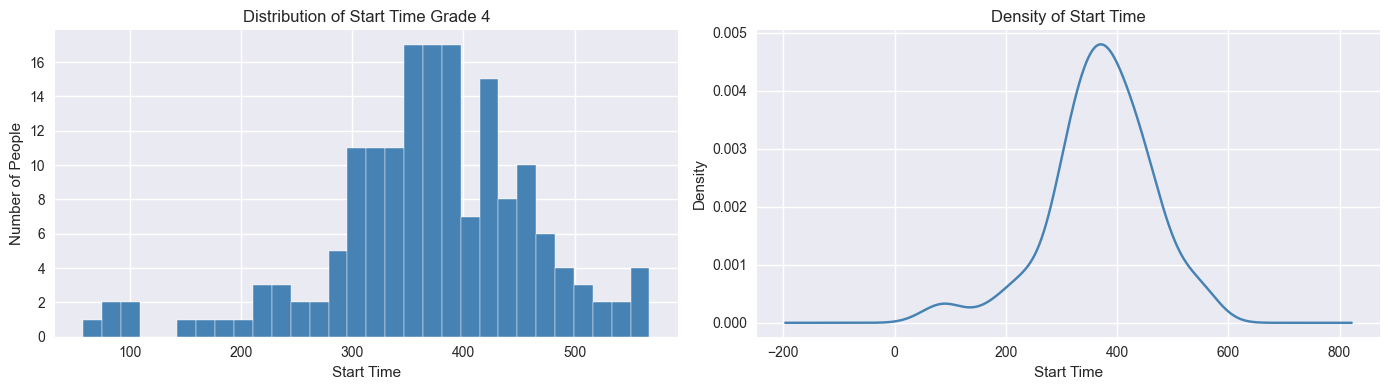

In [25]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np

plt.style.use('seaborn-v0_8')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

mask_grade_4 = summary_metrics_06['V06XRKL_Left'].eq(4) | summary_metrics_06['V06XRKL_Right'].eq(4)
mask_grade_3 = summary_metrics_06['V06XRKL_Left'].eq(3) | summary_metrics_06['V06XRKL_Right'].eq(3)
mask_grade_2 = summary_metrics_06['V06XRKL_Left'].eq(2) | summary_metrics_06['V06XRKL_Right'].eq(2)
mask_grade_1 = summary_metrics_06['V06XRKL_Left'].eq(1) | summary_metrics_06['V06XRKL_Right'].eq(1)
mask_grade_0 = summary_metrics_06['V06XRKL_Left'].eq(0) | summary_metrics_06['V06XRKL_Right'].eq(0)

# Histogram KL grade 4
axes[0].hist(summary_metrics_06.loc[mask_grade_4, 'wake_minute_mean'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Start Time')
axes[0].set_ylabel('Number of People')
axes[0].set_title('Distribution of Start Time Grade 4')

# KDE
summary_metrics_06.loc[mask_grade_4, 'wake_minute_mean'].plot.kde(ax=axes[1], color='steelblue')
axes[1].set_xlabel('Start Time')
axes[1].set_title('Density of Start Time')

plt.tight_layout()
plt.show()


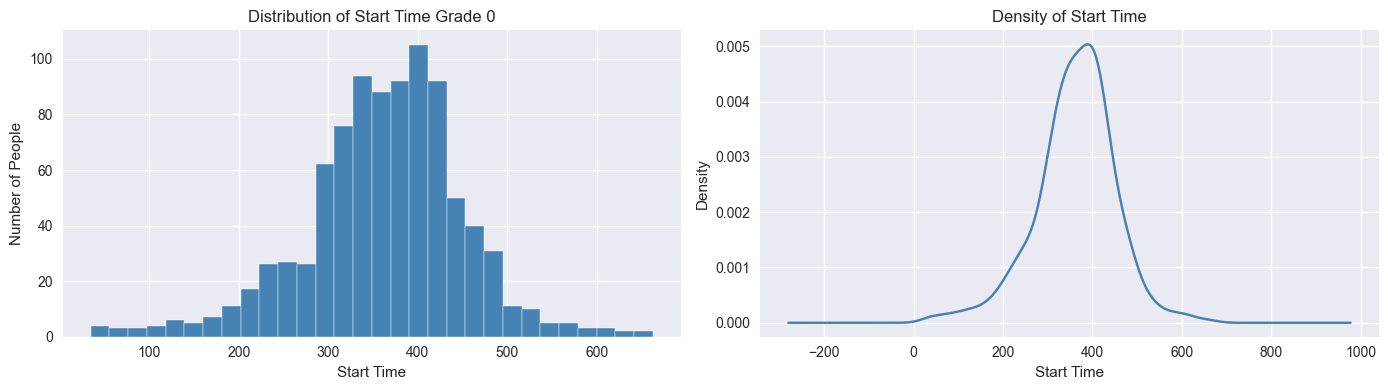

In [42]:
plt.style.use('seaborn-v0_8')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram KL grade 0
axes[0].hist(summary_metrics_06.loc[mask_grade_0, 'wake_minute_mean'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Start Time')
axes[0].set_ylabel('Number of People')
axes[0].set_title('Distribution of Start Time Grade 0')

# KDE
summary_metrics_06.loc[mask_grade_0, 'wake_minute_mean'].plot.kde(ax=axes[1], color='steelblue')
axes[1].set_xlabel('Start Time')
axes[1].set_title('Density of Start Time')

plt.tight_layout()
plt.show()

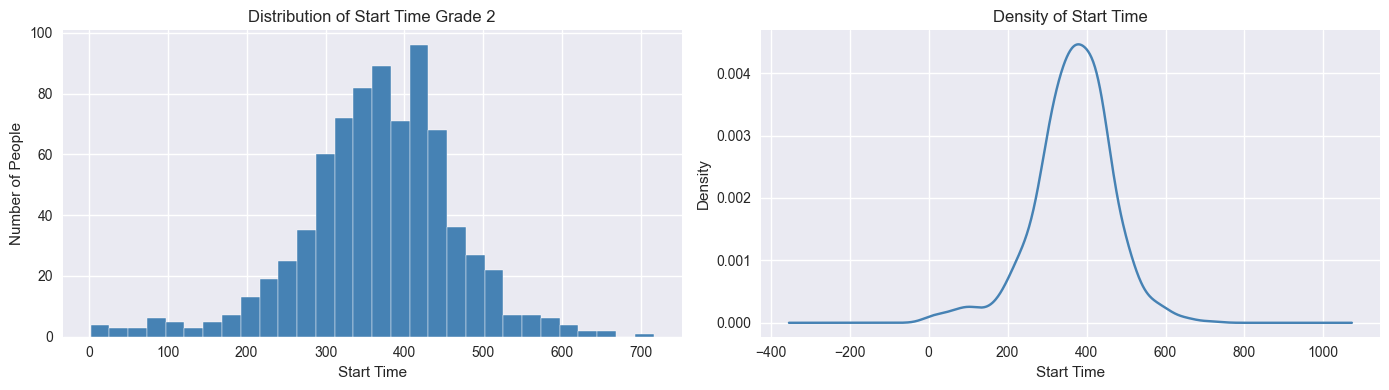

In [43]:
plt.style.use('seaborn-v0_8')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram KL grade 0
axes[0].hist(summary_metrics_06.loc[mask_grade_2, 'wake_minute_mean'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Start Time')
axes[0].set_ylabel('Number of People')
axes[0].set_title('Distribution of Start Time Grade 2')

# KDE
summary_metrics_06.loc[mask_grade_2, 'wake_minute_mean'].plot.kde(ax=axes[1], color='steelblue')
axes[1].set_xlabel('Start Time')
axes[1].set_title('Density of Start Time')

plt.tight_layout()
plt.show()

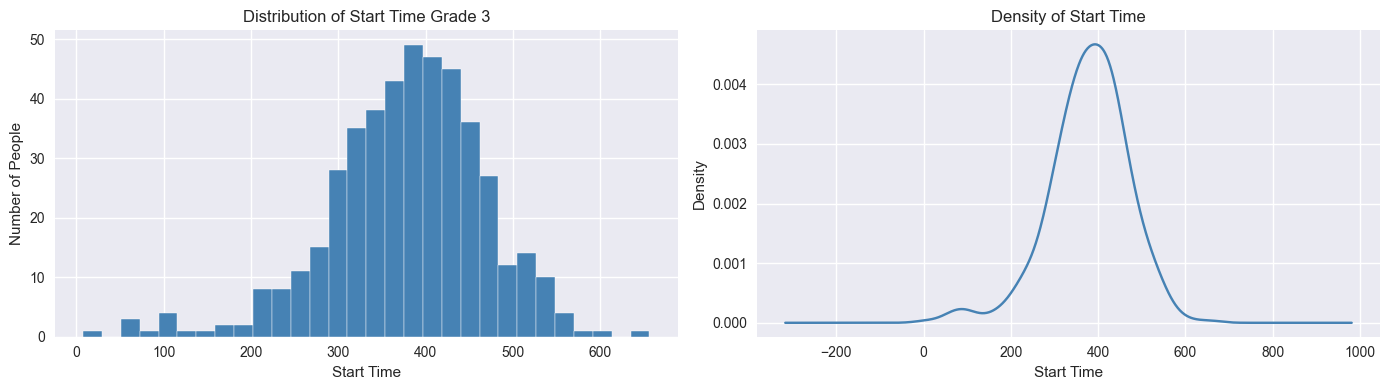

In [44]:
plt.style.use('seaborn-v0_8')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram KL grade 0
axes[0].hist(summary_metrics_06.loc[mask_grade_3, 'wake_minute_mean'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Start Time')
axes[0].set_ylabel('Number of People')
axes[0].set_title('Distribution of Start Time Grade 3')

# KDE
summary_metrics_06.loc[mask_grade_3, 'wake_minute_mean'].plot.kde(ax=axes[1], color='steelblue')
axes[1].set_xlabel('Start Time')
axes[1].set_title('Density of Start Time')

plt.tight_layout()
plt.show()

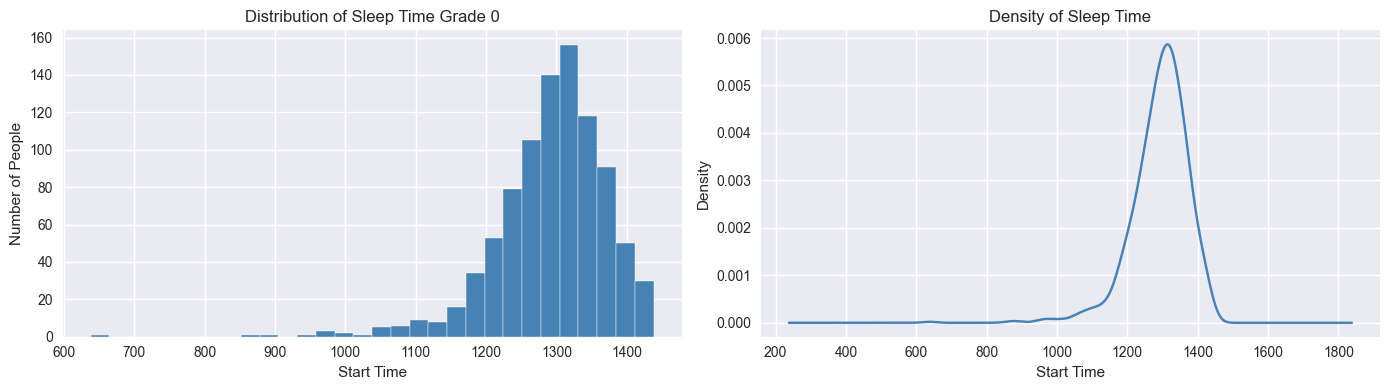

In [45]:
plt.style.use('seaborn-v0_8')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram KL grade 0
axes[0].hist(summary_metrics_06.loc[mask_grade_0, 'sleep_minute_mean'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Start Time')
axes[0].set_ylabel('Number of People')
axes[0].set_title('Distribution of Sleep Time Grade 0')

# KDE
summary_metrics_06.loc[mask_grade_0, 'sleep_minute_mean'].plot.kde(ax=axes[1], color='steelblue')
axes[1].set_xlabel('Start Time')
axes[1].set_title('Density of Sleep Time')

plt.tight_layout()
plt.show()

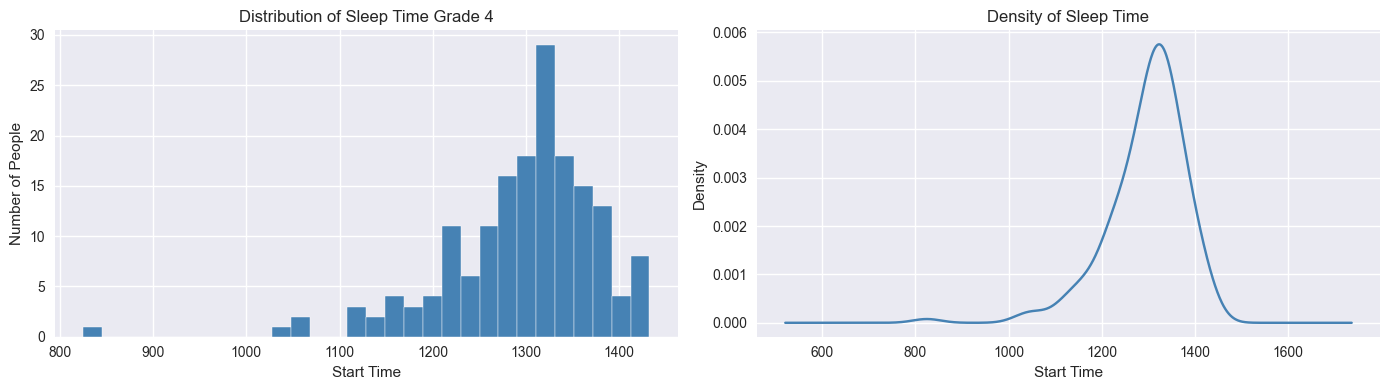

In [46]:
plt.style.use('seaborn-v0_8')

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Histogram KL grade 0
axes[0].hist(summary_metrics_06.loc[mask_grade_4, 'sleep_minute_mean'], bins=30, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Start Time')
axes[0].set_ylabel('Number of People')
axes[0].set_title('Distribution of Sleep Time Grade 4')

# KDE
summary_metrics_06.loc[mask_grade_4, 'sleep_minute_mean'].plot.kde(ax=axes[1], color='steelblue')
axes[1].set_xlabel('Start Time')
axes[1].set_title('Density of Sleep Time')

plt.tight_layout()
plt.show()

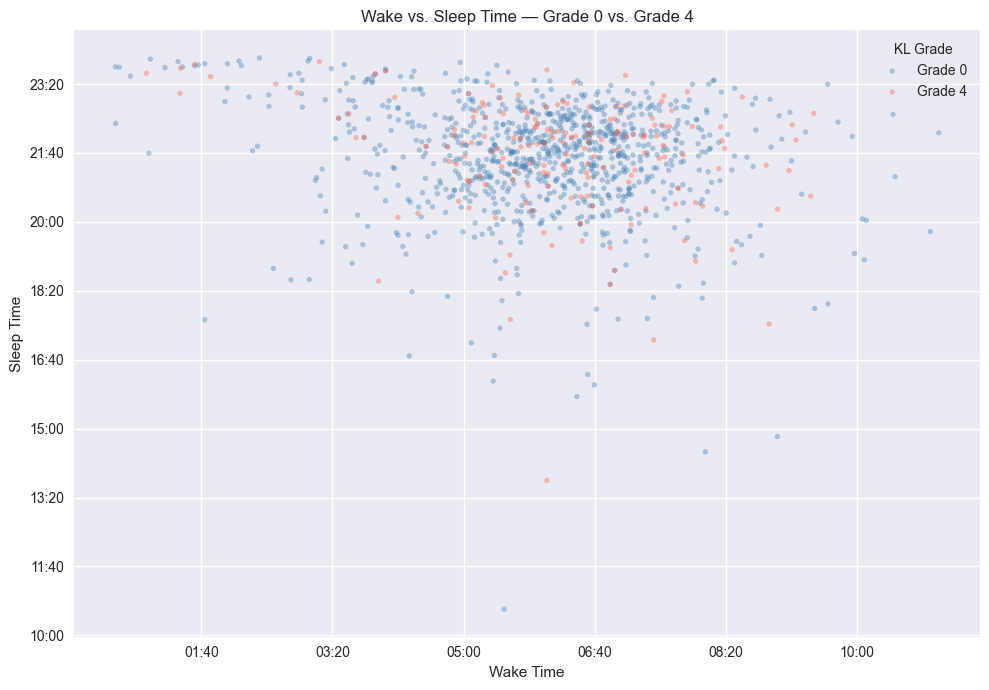

In [47]:
%matplotlib inline
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8')

# Outlier entfernen (optional, Schwellwert anpassen)
df_clean = summary_metrics_06[summary_metrics_06['sleep_minute_mean'] < 1440]

grades = {
    0: df_clean['V06XRKL_Left'].eq(0) | df_clean['V06XRKL_Right'].eq(0),
    4: df_clean['V06XRKL_Left'].eq(4) | df_clean['V06XRKL_Right'].eq(4),
}

colors = ['steelblue', 'tomato']

fig, ax = plt.subplots(figsize=(10, 7))

for (grade, mask), color in zip(grades.items(), colors):
    data = df_clean.loc[mask]
    ax.scatter(
        data['wake_minute_mean'],
        data['sleep_minute_mean'],
        label=f'Grade {grade}',
        color=color,
        alpha=0.4,
        s=15,
        edgecolors='none',
    )


# Achsen als Uhrzeit formatieren
def minutes_to_hhmm(x, _):
    h, m = divmod(int(x) % 1440, 60)
    return f'{h:02d}:{m:02d}'


ax.xaxis.set_major_formatter(plt.FuncFormatter(minutes_to_hhmm))
ax.yaxis.set_major_formatter(plt.FuncFormatter(minutes_to_hhmm))

ax.set_xlabel('Wake Time')
ax.set_ylabel('Sleep Time')
ax.set_title('Wake vs. Sleep Time — Grade 0 vs. Grade 4')
ax.legend(title='KL Grade')

plt.tight_layout()
plt.show()

In [48]:
from scipy.ndimage import gaussian_filter

worn_df = activity_df_big(Acceldatabymin06=Acceldatabymin06, daily_df_06=daily_06_df)

def plot_single_day_heatmap(
        worn_df: pd.DataFrame,
        patient_id: int,
        study_day: int,
        figure_output_path: Path | None = None,
) -> None:
    """
    Plots a thermal-style activity count heatmap for a single patient
    on a single day. A Gaussian blur is applied to smooth transitions
    between activity levels.

    :param worn_df: Output of ``activity_df_big`` with columns ID,
                    V06PAStudyDay, V06PAWeekDay, V06MinSequence and
                    V06MINCnt.
    :type worn_df: pd.DataFrame
    :param patient_id: Patient ID to plot.
    :type patient_id: int
    :param study_day: Study day to plot.
    :type study_day: int
    :param figure_output_path: Directory to save figures to. If ``None``,
                               figures are only displayed.
    :type figure_output_path: Path or None
    :return: None
    :rtype: None
    """
    day_data = worn_df[
        (worn_df["ID"] == patient_id) &
        (worn_df["V06PAStudyDay"] == study_day)
    ].copy()

    if day_data.empty:
        print(f"No data found for patient {patient_id} on day {study_day}.")
        return

    heatmap_row = np.zeros(shape=(1, 1440))

    for _, row in day_data.iterrows():
        minute_index = int(row["V06MinSequence"]) - 1
        if 0 <= minute_index < 1440:
            heatmap_row[0, minute_index] = row["V06MINCnt"]

    # repeat rows for visual height and apply gaussian blur
    heatmap_tiled = np.tile(heatmap_row, (40, 1))
    heatmap_smoothed = gaussian_filter(heatmap_tiled.astype(float), sigma=(3, 8))

    weekday = day_data["V06PAWeekDay"].iloc[0]

    figure, axis = plt.subplots(figsize=(16, 3))

    colormap = plt.cm.jet.copy()
    colormap.set_bad(color="black")   # NaN → schwarz
    colormap.set_under(color="black") # 0-Werte → schwarz

    axis.imshow(
        heatmap_smoothed,
        aspect="auto",
        cmap=colormap,
        interpolation="bilinear",
        vmin=1,   # alles unter 1 → schwarz
        vmax=np.percentile(heatmap_smoothed[heatmap_smoothed > 0], 95)
        if heatmap_smoothed.max() > 0 else 1,
    )

    hour_ticks = list(range(0, 1440, 60))
    hour_labels = [f"{hour:02d}:00" for hour in range(24)]
    axis.set_xticks(hour_ticks)
    axis.set_xticklabels(hour_labels, rotation=45, fontsize=7)
    axis.set_yticks([])

    axis.set_xlabel("Time of day")
    axis.set_title(
        f"Activity profile – Patient {patient_id} "
        f"| Day {study_day} ({weekday})"
    )

    plt.tight_layout()



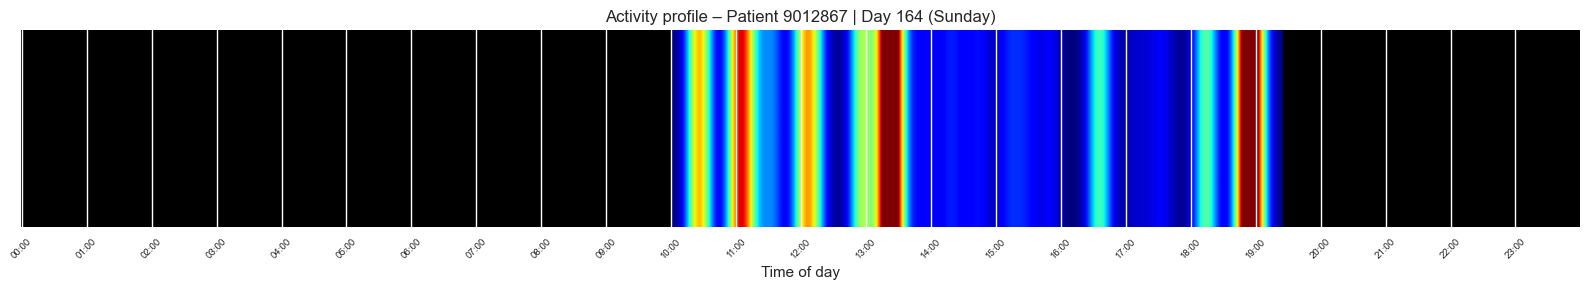

In [49]:
plot_single_day_heatmap(
    worn_df=worn_df,
    patient_id=9012867,
    study_day=164,
    figure_output_path=output_path / "figures",
)

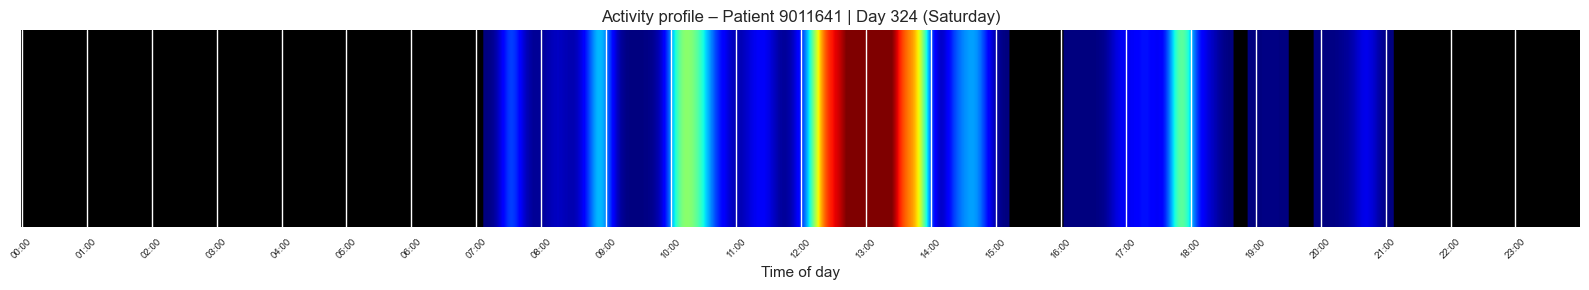

In [50]:
plot_single_day_heatmap(
    worn_df=worn_df,
    patient_id=9011641,
    study_day=324,
    figure_output_path=output_path / "figures",
)

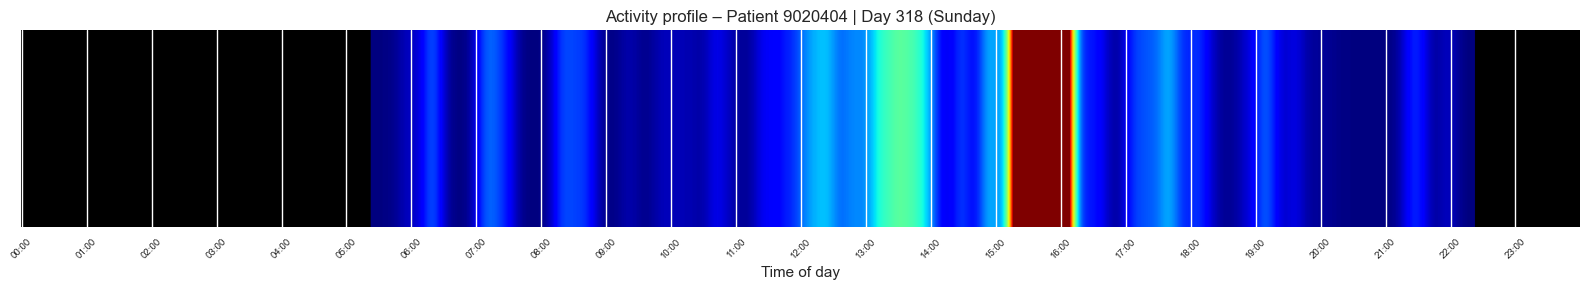

In [51]:
plot_single_day_heatmap(
    worn_df=worn_df,
    patient_id=9020404,
    study_day=318,
    figure_output_path=output_path / "figures",
)

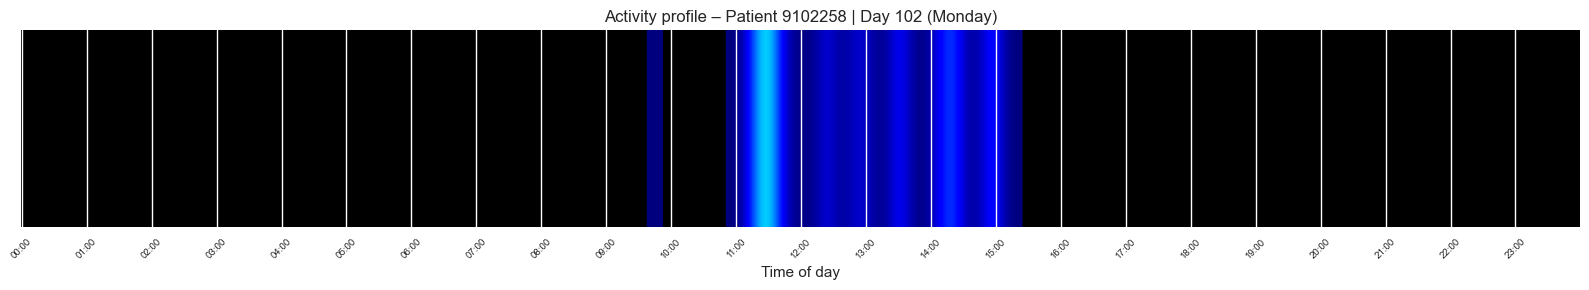

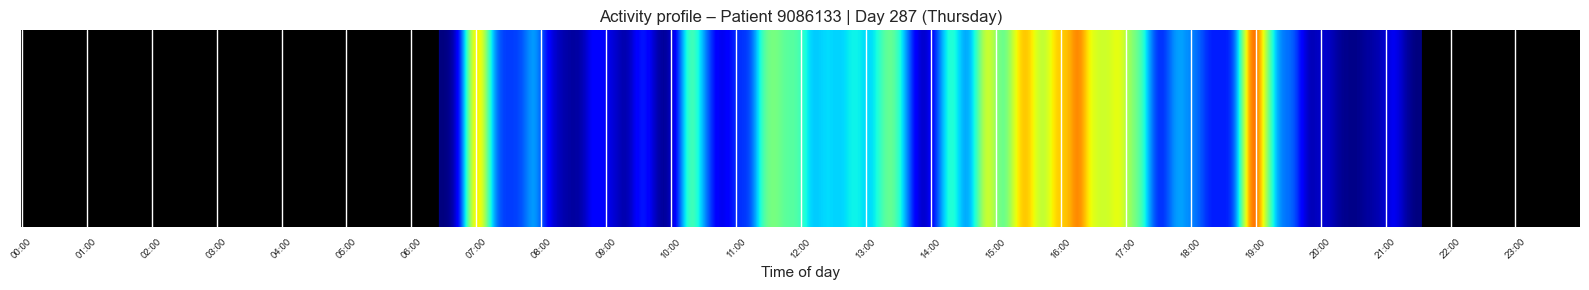

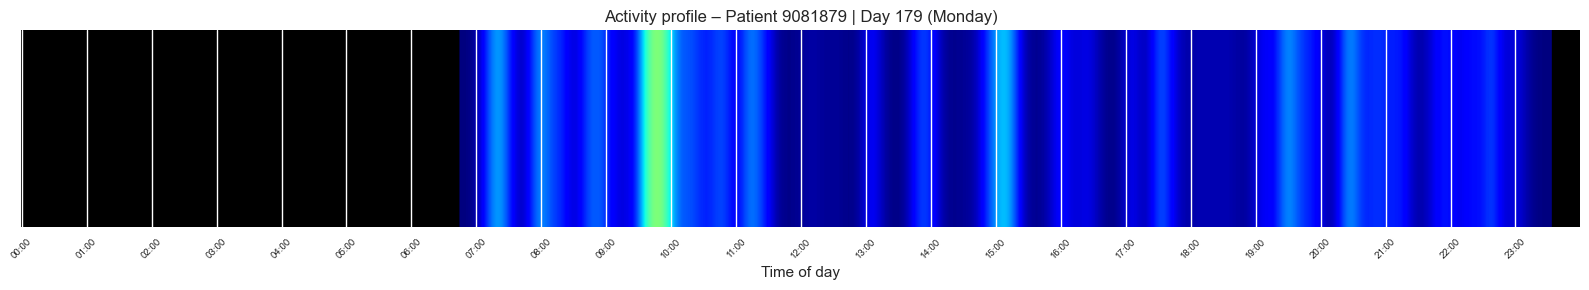

In [63]:
import matplotlib as matplotlib_base
from scipy.ndimage import gaussian_filter

# ── Plot 6: Single Day Thermal Heatmap ───────────────────────────────────────

def plot_single_day_heatmap(
        worn_df: pd.DataFrame,
        patient_id: int,
        study_day: int,
        global_vmax: float | None = None,
        figure_output_path: Path | None = None,
) -> None:
    """
    Plots a thermal-style activity count heatmap for a single patient
    on a single day. A Gaussian blur is applied to smooth transitions
    between activity levels.

    :param worn_df: Output of ``activity_df_big`` with columns ID,
                    V06PAStudyDay, V06PAWeekDay, V06MinSequence and
                    V06MINCnt.
    :type worn_df: pd.DataFrame
    :param patient_id: Patient ID to plot.
    :type patient_id: int
    :param study_day: Study day to plot.
    :type study_day: int
    :param global_vmax: Maximum value for the color scale. If ``None``,
                        the 95th percentile of the patient's own data
                        is used.
    :type global_vmax: float or None
    :param figure_output_path: Directory to save figures to. If ``None``,
                               figures are only displayed.
    :type figure_output_path: Path or None
    :return: None
    :rtype: None
    """
    day_data = worn_df[
        (worn_df["ID"] == patient_id) &
        (worn_df["V06PAStudyDay"] == study_day)
    ].copy()

    if day_data.empty:
        print(f"No data found for patient {patient_id} on day {study_day}.")
        return

    heatmap_row = np.zeros(shape=(1, 1440))

    for _, row in day_data.iterrows():
        minute_index = int(row["V06MinSequence"]) - 1
        if 0 <= minute_index < 1440:
            heatmap_row[0, minute_index] = row["V06MINCnt"]

    heatmap_tiled = np.tile(heatmap_row, (40, 1))
    heatmap_smoothed = gaussian_filter(heatmap_tiled.astype(float), sigma=(3, 8))

    colormap = matplotlib_base.colormaps["jet"].copy()
    colormap.set_bad(color="black")
    colormap.set_under(color="black")

    vmax = global_vmax if global_vmax is not None else (
        np.percentile(heatmap_smoothed[heatmap_smoothed > 0], 95)
        if heatmap_smoothed.max() > 0 else 1
    )

    weekday = day_data["V06PAWeekDay"].iloc[0]

    figure, axis = plt.subplots(figsize=(16, 3))

    axis.imshow(
        heatmap_smoothed,
        aspect="auto",
        cmap=colormap,
        interpolation="bilinear",
        vmin=1,
        vmax=vmax,
    )

    hour_ticks = list(range(0, 1440, 60))
    hour_labels = [f"{hour:02d}:00" for hour in range(24)]
    axis.set_xticks(hour_ticks)
    axis.set_xticklabels(hour_labels, rotation=45, fontsize=7)
    axis.set_yticks([])

    axis.set_xlabel("Time of day")
    axis.set_title(
        f"Activity profile – Patient {patient_id} "
        f"| Day {study_day} ({weekday})"
    )

    plt.tight_layout()

    save_or_show(
        figure=figure,
        figure_output_path=figure_output_path,
        filename=f"heatmap_single_day_{patient_id}_day{study_day}",
    )


# ── Usage ─────────────────────────────────────────────────────────────────────

global_vmax = np.percentile(
    worn_df["V06MINCnt"][worn_df["V06MINCnt"] > 0].values, 95
)

def save_or_show(
        figure: plt.Figure,
        figure_output_path: Path | None,
        filename: str,
) -> None:
    """
    Saves a figure to disk if a path is provided, then displays it.

    :param figure: Matplotlib figure to save or show.
    :type figure: plt.Figure
    :param figure_output_path: Directory to save the figure to. If
                               ``None``, only displays the figure.
    :type figure_output_path: Path or None
    :param filename: Filename without extension.
    :type filename: str
    :return: None
    :rtype: None
    """
    if figure_output_path is not None:
        figure_output_path.mkdir(parents=True, exist_ok=True)
        figure.savefig(
            figure_output_path / f"{filename}.png",
            dpi=150,
            bbox_inches="tight",
        )
    plt.show()

for patient_id, study_day in [(9102258, 102), (9086133, 287), (9081879, 179)]:
    plot_single_day_heatmap(
        worn_df=worn_df,
        patient_id=patient_id,
        study_day=study_day,
        global_vmax=global_vmax,
        figure_output_path=output_path / "figures",
    )